# Ejercicio 04 · Clasificador visual con CNN y Model Card

**INF-8239 Ciencia de Datos II · Unidad 02 · LAB07** — Fashion-MNIST: baseline denso frente a CNN.

Este notebook reúne la evidencia del ejercicio **sin reentrenar**: carga los modelos guardados en
`models/`, recalcula las métricas sobre la partición de prueba y comprueba que coinciden con los
archivos de `reports/` generados por `scripts/train_cv.py`.

**Requisitos previos** (ver README): `uv sync --extra cpu` y, si `models/` o `reports/` no existen,
`uv run python scripts/train_cv.py --epochs 8`. Para reejecutar este notebook:
`uv run jupyter nbconvert --to notebook --execute --inplace notebooks/ejercicio04.ipynb`.

In [1]:
import csv
import json
import os
import subprocess
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
import numpy as np
import tensorflow as tf
from IPython.display import Image, Markdown, display
from sklearn.metrics import f1_score

from inf8239_u02_cv.data import CLASS_NAMES, normalize_images, validate_images

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS, MODELS = ROOT / "reports", ROOT / "models"
metrics = json.loads((REPORTS / "cv_metrics.json").read_text(encoding="utf-8"))
history = json.loads((REPORTS / "training_history.json").read_text(encoding="utf-8"))
runtime = json.loads((REPORTS / "runtime.json").read_text(encoding="utf-8"))
summary = json.loads((REPORTS / "data_summary.json").read_text(encoding="utf-8"))
per_class = list(csv.DictReader((REPORTS / "per_class_metrics.csv").open(encoding="utf-8")))
LABELS = {"dense": "Densa (baseline)", "cnn": "CNN"}


def table(header, rows):
    lines = ["| " + " | ".join(header) + " |", "|" + "---|" * len(header)]
    lines += ["| " + " | ".join(str(cell) for cell in row) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

## 1 · Entorno de la ejecución registrada

In [2]:
table(["Campo", "Valor"], [[key, value] for key, value in runtime.items()])

| Campo | Valor |
|---|---|
| cpu | AMD Ryzen 5 5600X 6-Core Processor |
| logical_cores | 12 |
| device | CPU |
| os | Windows-11-10.0.26300-SP0 |
| python | 3.12.14 |
| tensorflow | 2.21.0 |

## 2 · Auditoría y partición reproducible

Se reconstruye la misma partición que usa `train_cv.py` (últimas 6.000 imágenes de entrenamiento
como validación), se validan las tres particiones y se compara el conteo por clase con
`data_summary.json`.

In [3]:
(x_all, y_all), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_all, x_test = normalize_images(x_all), normalize_images(x_test)
splits = {
    "entrenamiento": (x_all[:-6000], y_all[:-6000]),
    "validación": (x_all[-6000:], y_all[-6000:]),
    "prueba": (x_test, y_test),
}
rows = []
for name, (images, labels) in splits.items():
    validate_images(images, labels)
    counts = dict(zip(CLASS_NAMES, np.bincount(labels, minlength=len(CLASS_NAMES)).tolist()))
    assert counts == summary[name]["per_class"], f"{name} no coincide con data_summary.json"
    rows.append([name, images.shape, f"{images.min():.1f}–{images.max():.1f}",
                 f"{min(counts.values())}–{max(counts.values())}"])
table(["Partición", "Forma", "Rango", "Imágenes por clase"], rows)
print("Las tres particiones pasan validate_images y coinciden con data_summary.json")

| Partición | Forma | Rango | Imágenes por clase |
|---|---|---|---|
| entrenamiento | (54000, 28, 28, 1) | 0.0–1.0 | 5367–5445 |
| validación | (6000, 28, 28, 1) | 0.0–1.0 | 555–633 |
| prueba | (10000, 28, 28, 1) | 0.0–1.0 | 1000–1000 |

Las tres particiones pasan validate_images y coinciden con data_summary.json


## 3 · Curvas de entrenamiento y validación

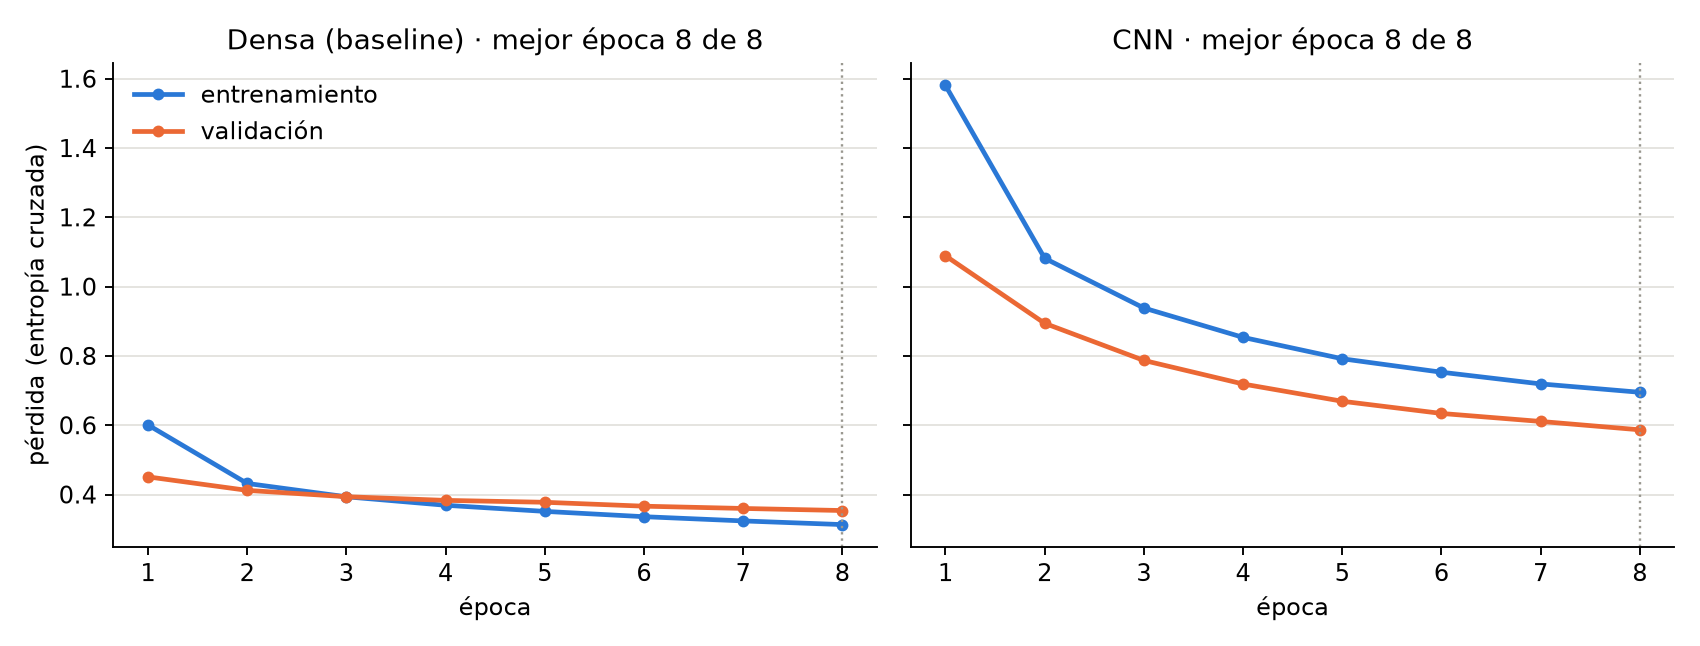

| Modelo | Pérdida entrenamiento | Pérdida validación | Mejora en la última época | Mejor época |
|---|---|---|---|---|
| Densa (baseline) | 0.601 → 0.313 | 0.451 → 0.354 | 0.006 | 8 de 8 |
| CNN | 1.581 → 0.695 | 1.089 → 0.587 | 0.024 | 8 de 8 |

In [4]:
display(Image(filename=str(REPORTS / "learning_curves.png"), width=900))
rows = []
for name, h in history.items():
    best = int(np.argmin(h["val_loss"])) + 1
    rows.append([LABELS[name], f"{h['loss'][0]:.3f} → {h['loss'][-1]:.3f}",
                 f"{h['val_loss'][0]:.3f} → {h['val_loss'][-1]:.3f}",
                 f"{h['val_loss'][-2] - h['val_loss'][-1]:.3f}", f"{best} de {len(h['val_loss'])}"])
table(["Modelo", "Pérdida entrenamiento", "Pérdida validación", "Mejora en la última época",
       "Mejor época"], rows)

**Lectura.** Ninguno de los dos modelos sobreajusta: la pérdida de validación baja en todas las
épocas. La CNN está **subentrenada**: su pérdida de validación queda casi al doble de la densa y
todavía mejoraba en la última época, que fue la mejor. El límite de 8 épocas cortó su aprendizaje.

## 4 · Métricas recalculadas desde los modelos guardados

In [5]:
rows, predictions = [], {}
for name in ("dense", "cnn"):
    model = tf.keras.models.load_model(MODELS / f"{name}.keras")
    predictions[name] = model.predict(x_test, verbose=0).argmax(axis=1)
    f1 = f1_score(y_test, predictions[name], average="macro")
    accuracy = float((predictions[name] == y_test).mean())
    assert np.isclose(f1, metrics[name]["f1_macro"]), f"F1 de {name} no coincide con cv_metrics.json"
    assert np.isclose(accuracy, metrics[name]["accuracy"])
    rows.append([LABELS[name], f"{f1:.3f}", f"{accuracy:.3f}", f"{metrics[name]['f1_macro']:.3f}"])
table(["Modelo", "F1 macro (recalculado)", "Accuracy (recalculada)", "F1 en cv_metrics.json"], rows)
print("Los modelos guardados reproducen exactamente las métricas registradas")

| Modelo | F1 macro (recalculado) | Accuracy (recalculada) | F1 en cv_metrics.json |
|---|---|---|---|
| Densa (baseline) | 0.865 | 0.866 | 0.865 |
| CNN | 0.789 | 0.793 | 0.789 |

Los modelos guardados reproducen exactamente las métricas registradas


In [6]:
recall = {(row["model"], row["class"]): float(row["recall"]) for row in per_class}
f1_class = {(row["model"], row["class"]): float(row["f1"]) for row in per_class}
rows = sorted(([c, f"{recall[('dense', c)]:.3f}", f"{recall[('cnn', c)]:.3f}",
                f"{f1_class[('dense', c)]:.3f}", f"{f1_class[('cnn', c)]:.3f}"] for c in CLASS_NAMES),
              key=lambda row: float(row[2]))
table(["Clase", "Recall densa", "Recall CNN", "F1 densa", "F1 CNN"], rows)

| Clase | Recall densa | Recall CNN | F1 densa | F1 CNN |
|---|---|---|---|---|
| Camisa | 0.597 | 0.374 | 0.652 | 0.428 |
| Jersey | 0.684 | 0.642 | 0.752 | 0.672 |
| Abrigo | 0.870 | 0.663 | 0.782 | 0.662 |
| Camiseta/top | 0.848 | 0.807 | 0.819 | 0.717 |
| Vestido | 0.903 | 0.843 | 0.869 | 0.796 |
| Sandalia | 0.962 | 0.885 | 0.948 | 0.916 |
| Botín | 0.937 | 0.896 | 0.952 | 0.915 |
| Pantalón | 0.969 | 0.932 | 0.975 | 0.959 |
| Bolso | 0.953 | 0.937 | 0.963 | 0.927 |
| Zapatilla | 0.940 | 0.952 | 0.934 | 0.901 |

**Lectura.** Camisa es la clase más difícil para los dos modelos. Las clases débiles son siempre
prendas superiores; calzado, bolsos y pantalones superan el 88 % de recall en ambos.

## 5 · Matrices de confusión

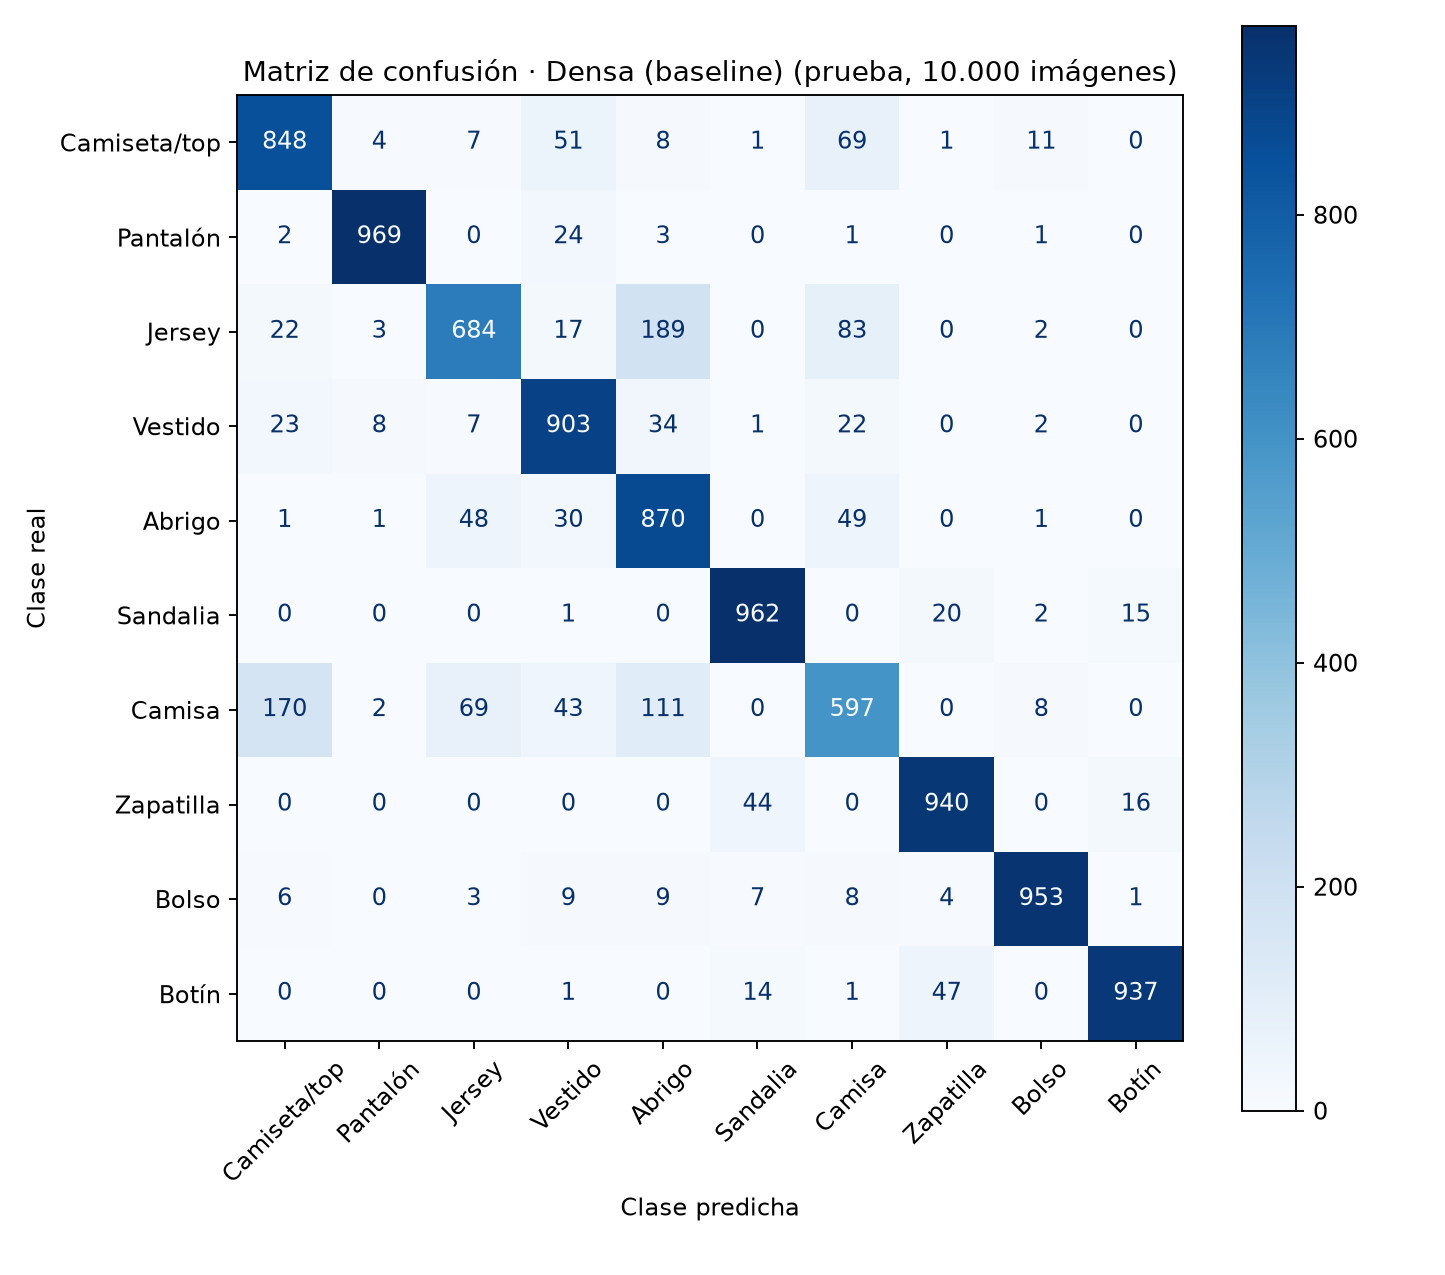

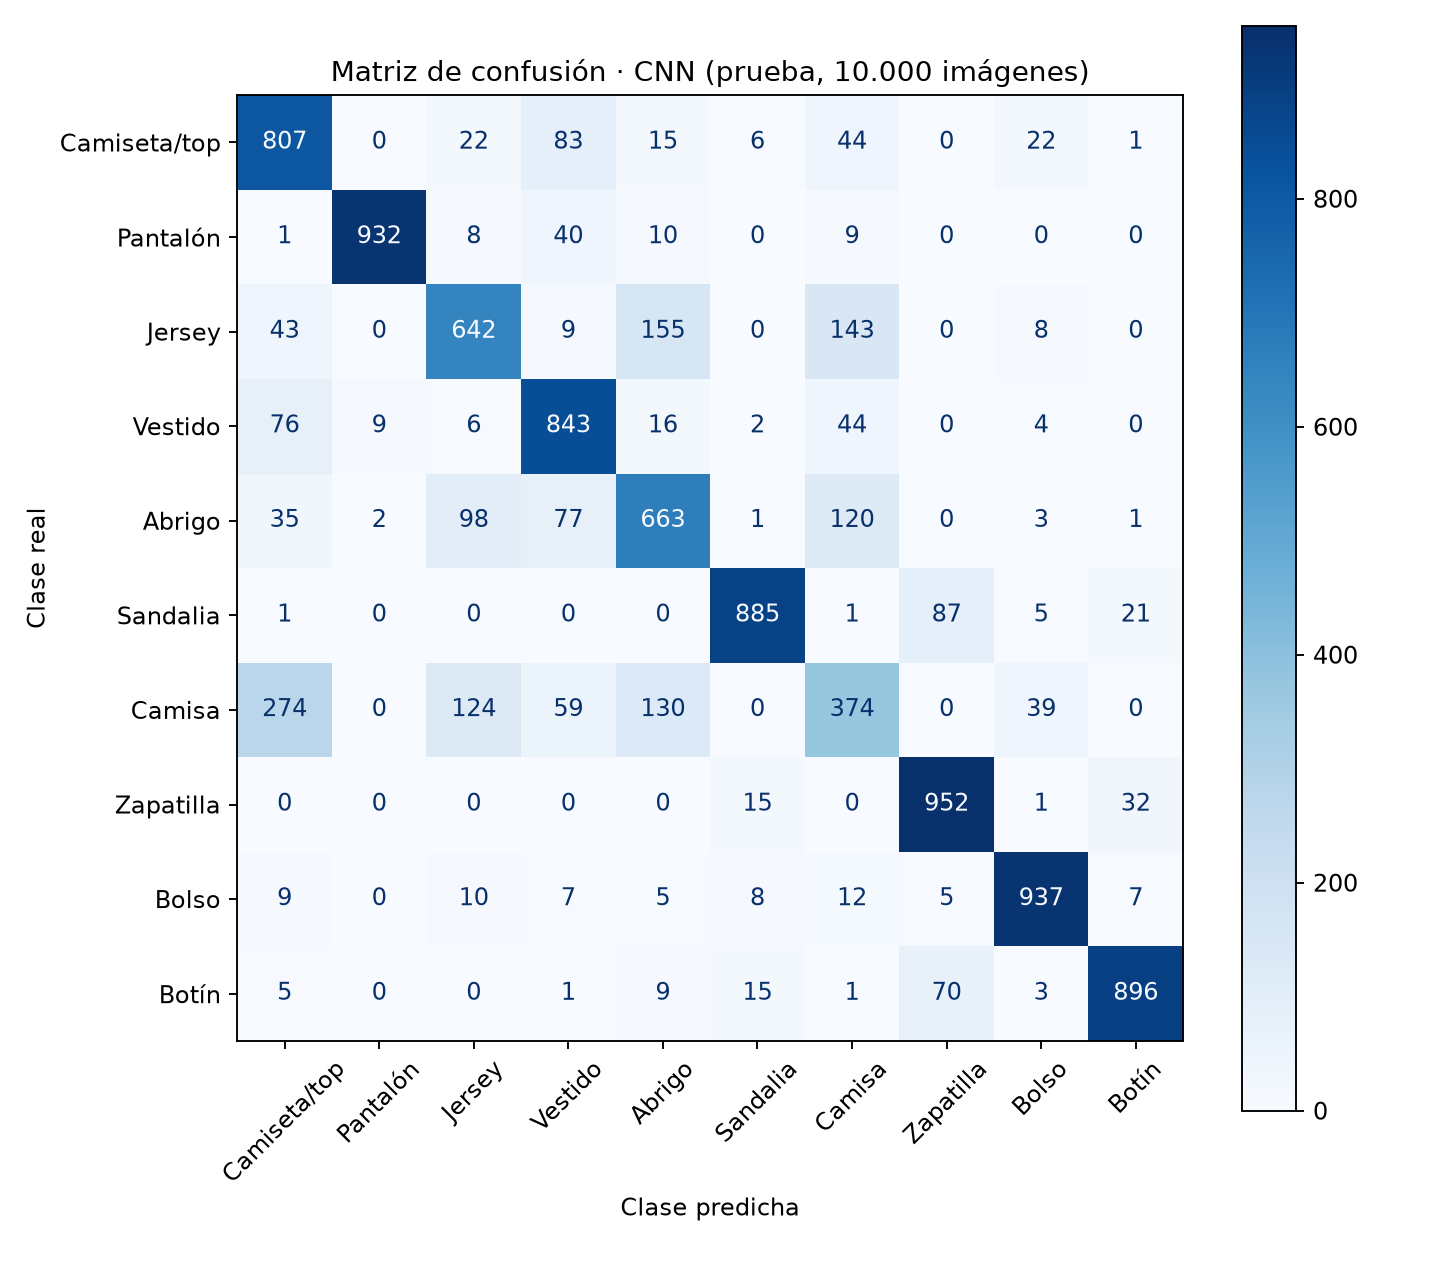

In [7]:
for name in ("dense", "cnn"):
    display(Image(filename=str(REPORTS / f"confusion_{name}.png"), width=620))

Las dos matrices muestran el mismo patrón: los errores se concentran entre Camisa,
Camiseta/top, Jersey y Abrigo.

## 6 · Errores visuales de la CNN

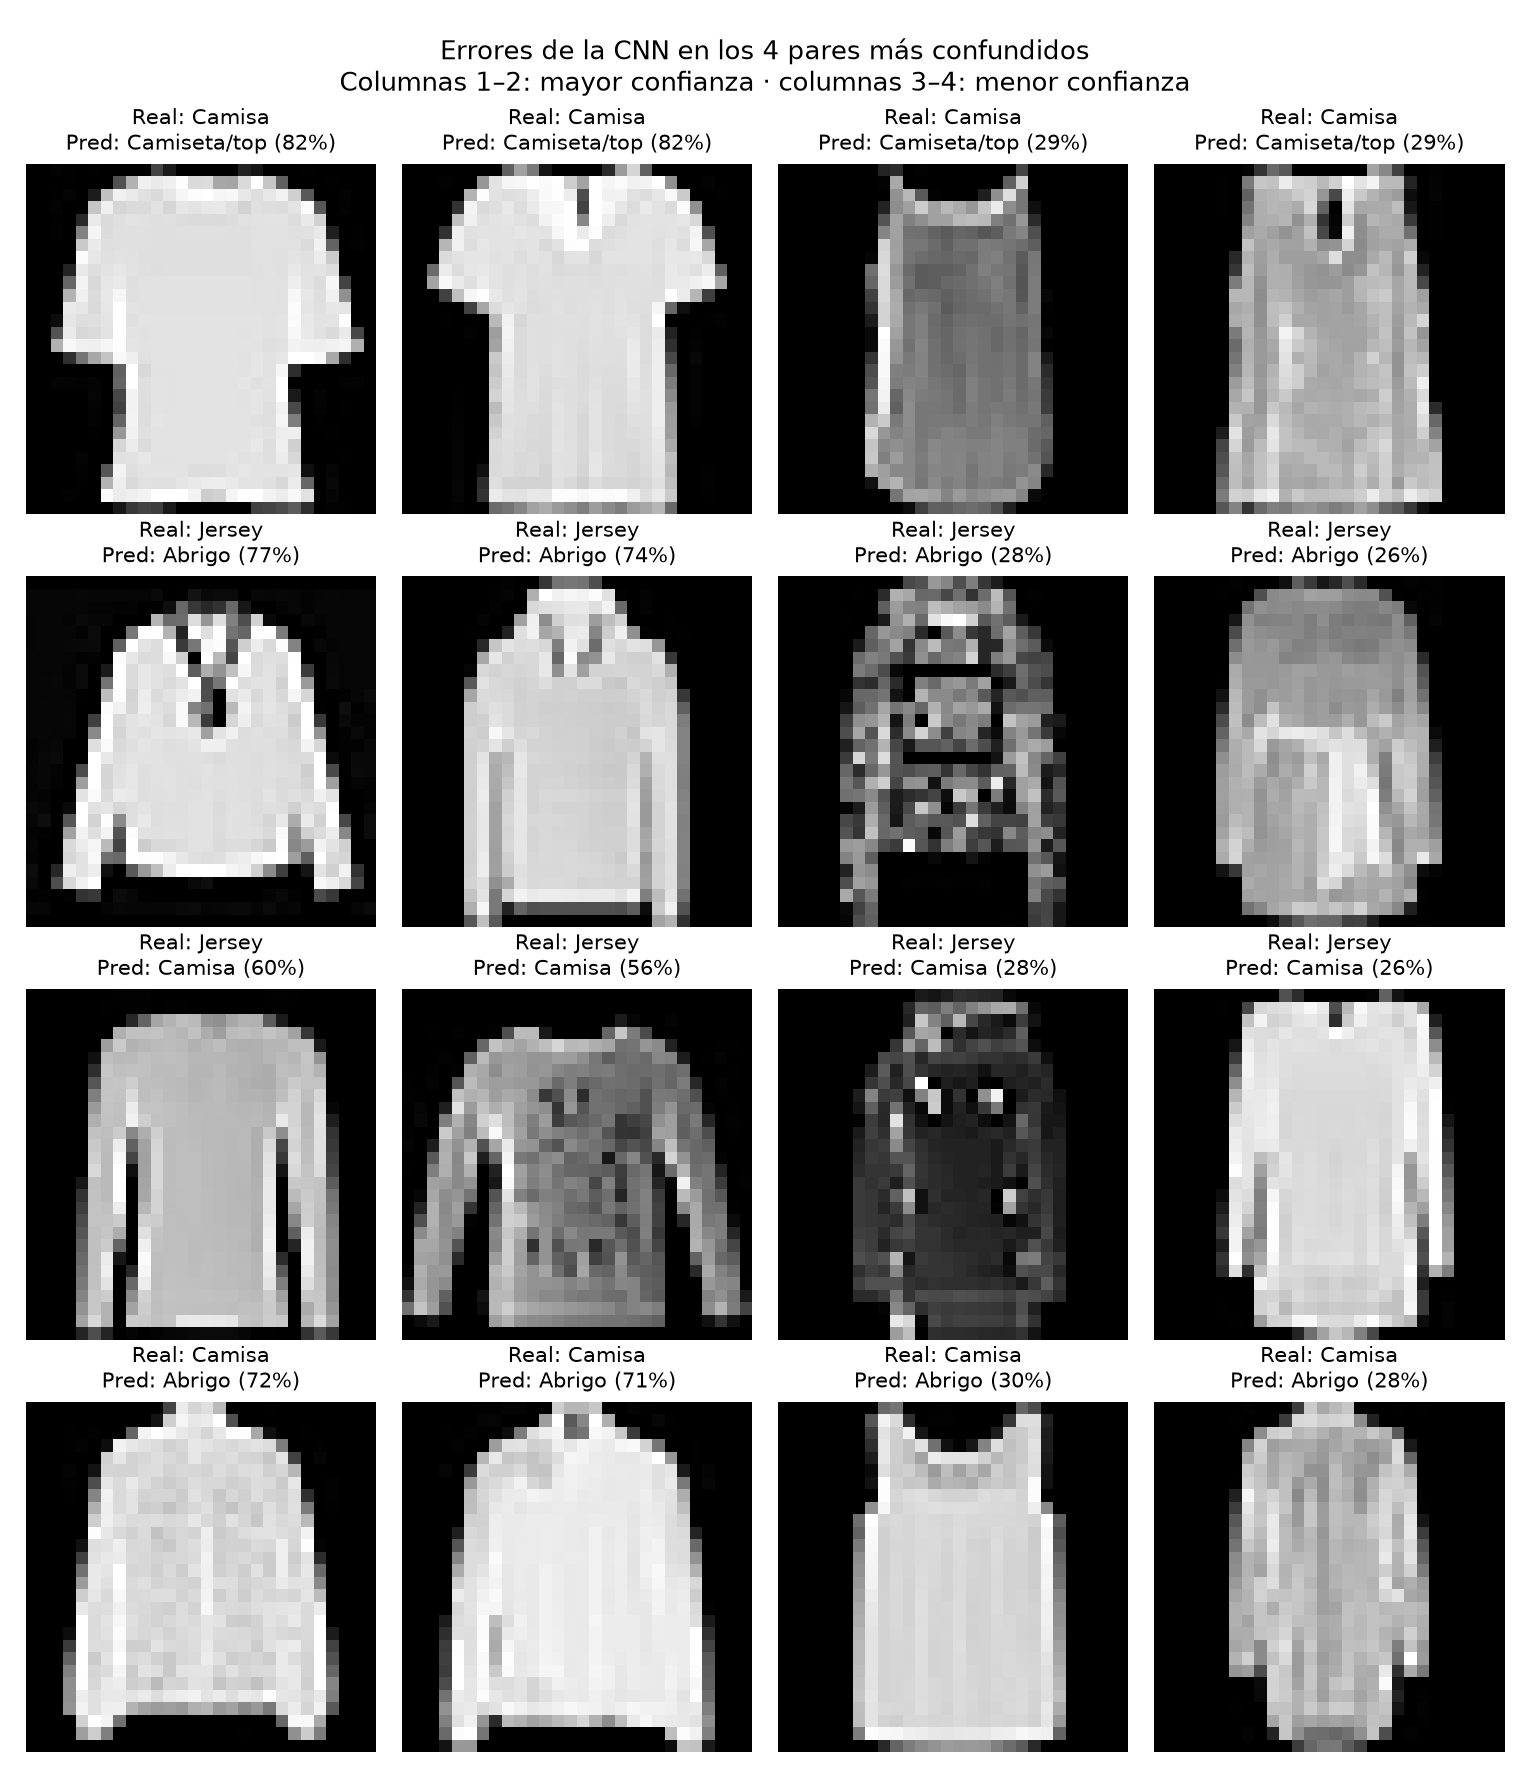

| Imagen | Real | Predicción | Confianza | Prob. clase real | Grupo |
|---|---|---|---|---|---|
| 4140 | Camisa | Camiseta/top | 82% | 8% | mayor confianza |
| 9122 | Camisa | Camiseta/top | 82% | 7% | mayor confianza |
| 3488 | Camisa | Camiseta/top | 29% | 23% | menor confianza |
| 6363 | Camisa | Camiseta/top | 29% | 16% | menor confianza |
| 8009 | Jersey | Abrigo | 77% | 7% | mayor confianza |
| 9337 | Jersey | Abrigo | 74% | 11% | mayor confianza |
| 4363 | Jersey | Abrigo | 28% | 24% | menor confianza |
| 3554 | Jersey | Abrigo | 26% | 14% | menor confianza |
| 3301 | Jersey | Camisa | 60% | 21% | mayor confianza |
| 9443 | Jersey | Camisa | 56% | 9% | mayor confianza |
| 8624 | Jersey | Camisa | 28% | 6% | menor confianza |
| 4674 | Jersey | Camisa | 26% | 24% | menor confianza |
| 4079 | Camisa | Abrigo | 72% | 11% | mayor confianza |
| 7004 | Camisa | Abrigo | 71% | 14% | mayor confianza |
| 2986 | Camisa | Abrigo | 30% | 28% | menor confianza |
| 5168 | Camisa | Abrigo | 28% | 19% | menor confianza |

In [8]:
display(Image(filename=str(REPORTS / "cnn_errors.png"), width=760))
examples = list(csv.DictReader((REPORTS / "cnn_error_examples.csv").open(encoding="utf-8")))
table(["Imagen", "Real", "Predicción", "Confianza", "Prob. clase real", "Grupo"],
      [[e["test_index"], e["real"], e["predicted"], f"{float(e['confidence']):.0%}",
        f"{float(e['real_class_probability']):.0%}", e["group"]] for e in examples])

**Lectura.** Las cuatro confusiones más frecuentes ocurren entre prendas superiores con la misma
silueta. Hay errores con hasta 82 % de confianza (el modelo no duda) y casos ambiguos cerca del
empate. Algunas prendas sin mangas etiquetadas como Camisa sugieren etiquetas discutibles.
Análisis caso por caso en `reports/lab07_analisis.md`.

## 7 · Costo computacional y decisión (Green AI)

In [9]:
d, c = metrics["dense"], metrics["cnn"]
macs = {"dense": 784 * 64 + 64 * 10, "cnn": 28 * 28 * 32 * 9 + 14 * 14 * 64 * 9 * 32 + 64 * 10}
table(["Criterio", "Densa", "CNN", "CNN frente a densa"], [
    ["F1 macro", f"{d['f1_macro']:.3f}", f"{c['f1_macro']:.3f}", f"{c['f1_macro'] - d['f1_macro']:+.3f}"],
    ["Parámetros", f"{d['parameters']:,}", f"{c['parameters']:,}", f"{c['parameters'] / d['parameters'] - 1:+.0%}"],
    ["Archivo del modelo", f"{d['model_file_kb']} KB", f"{c['model_file_kb']} KB",
     f"{c['model_file_kb'] / d['model_file_kb'] - 1:+.0%}"],
    ["Multiplicaciones-acumulaciones por imagen", f"{macs['dense']:,}", f"{macs['cnn']:,}",
     f"×{macs['cnn'] / macs['dense']:.0f}"],
    ["Entrenamiento (8 épocas)", f"{d['train_seconds']:.1f} s", f"{c['train_seconds']:.1f} s",
     f"×{c['train_seconds'] / d['train_seconds']:.1f}"],
    ["Inferencia (mediana de 5)", f"{d['inference_ms_per_image']:.3f} ms", f"{c['inference_ms_per_image']:.3f} ms",
     f"×{c['inference_ms_per_image'] / d['inference_ms_per_image']:.1f}"],
])
print("Tiempos de la ejecución registrada en", runtime["cpu"], "·", runtime["device"])

| Criterio | Densa | CNN | CNN frente a densa |
|---|---|---|---|
| F1 macro | 0.865 | 0.789 | -0.075 |
| Parámetros | 50,890 | 19,466 | -62% |
| Archivo del modelo | 215.5 KB | 102.9 KB | -52% |
| Multiplicaciones-acumulaciones por imagen | 50,816 | 3,839,104 | ×76 |
| Entrenamiento (8 épocas) | 5.2 s | 51.6 s | ×10.0 |
| Inferencia (mediana de 5) | 0.027 ms | 0.055 ms | ×2.0 |

Tiempos de la ejecución registrada en AMD Ryzen 5 5600X 6-Core Processor · CPU


**Decisión.** Con 8 épocas la CNN no mejora: es peor en F1 y además más costosa en entrenamiento
e inferencia, aunque tenga menos parámetros. Se mantiene el baseline denso. La comparación vale
para este presupuesto de épocas; entrenar la CNN hasta converger exigiría repetir la tabla.

## 8 · Pruebas automatizadas

In [10]:
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider",
                         "--color=no"], cwd=ROOT, capture_output=True, text=True)
print(result.stdout.strip().splitlines()[-1])

15 passed in 5.05s


## Conclusión

Los modelos guardados reproducen exactamente las métricas registradas y la partición coincide con
la documentada. Con 8 épocas, el baseline denso (F1 0,865) supera a la CNN (0,789), que está
subentrenada y cuesta más. Fashion-MNIST es un benchmark didáctico: estos resultados no son válidos
para fotografías reales ni para otros dominios. Cierre interpretativo completo en el README y ficha
del modelo en `MODEL_CARD.md`.